In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

print("Librerías cargadas")

Librerías cargadas


In [10]:
# Cargar facturas
facturas = pd.read_csv(
    "facturas.txt",
    sep=";",
    header=None,
    names=["fecha", "hora", "cliente", "tipo_cliente", "producto", "precio_unit", "cantidad"]
)

# Cargar productos
productos = pd.read_csv(
    "productos.txt",
    sep=";",
    header=None,
    names=["id", "nombre", "categoria", "precio", "stock"]
)

# Cargar clientes
clientes = pd.read_csv(
    "clientes.txt",
    sep=";",
    header=None,
    names=["id", "nombre", "telefono", "tipo"]
)

print("Archivos cargados")
print(f"Facturas: {len(facturas)} filas")
print(f"Productos: {len(productos)} filas")
print(f"Clientes: {len(clientes)} filas")

Archivos cargados
Facturas: 36500 filas
Productos: 200 filas
Clientes: 100 filas


In [11]:
# Convertir fecha y hora
facturas["fecha"] = pd.to_datetime(facturas["fecha"])
facturas["hora"] = pd.to_datetime(
    facturas["hora"],
    format="%H:%M:%S"
).dt.hour

# Calcular total por línea
facturas["total"] = (
    facturas["precio_unit"] *
    facturas["cantidad"]
)

# Extraer mes
facturas["mes"] = facturas["fecha"].dt.month
facturas["nombre_mes"] = facturas["fecha"].dt.strftime("%b")

# Día de semana
facturas["dia_semana"] = facturas["fecha"].dt.day_name()

# Limpiar espacios
facturas["cliente"] = facturas["cliente"].str.strip()
facturas["producto"] = facturas["producto"].str.strip()

# Unir categorías
merge_cat = productos[["nombre", "categoria"]].copy()
merge_cat.columns = ["producto", "categoria"]

facturas = facturas.merge(
    merge_cat,
    on="producto",
    how="left"
)

facturas["categoria"] = facturas["categoria"].fillna("Sin categoría")

print("Datos limpios")
facturas.head()

Datos limpios


,fecha,hora,cliente,tipo_cliente,producto,precio_unit,cantidad,total,mes,nombre_mes,dia_semana,categoria
0,2025-01-01,12,Diego Paredes,Afiliado,Tijeras 1u,1.50,6,9.00,1,Jan,Wednesday,Otros
1,2025-01-01,10,Esteban Bravo,Afiliado,Kombucha 350ml,2.80,7,19.60,1,Jan,Wednesday,Bebidas
2,2025-01-01,8,Tomás Oña,Afiliado,Espinaca 250g,0.75,7,5.25,1,Jan,Wednesday,Frutas y Verduras
3,2025-01-01,14,Claudia Espinoza,Afiliado,Chuleta cerdo 500g,3.60,3,10.80,1,Jan,Wednesday,Carnes
4,2025-01-01,18,Silvia Cabrera,Afiliado,Papa chola 2kg,1.60,4,6.40,1,Jan,Wednesday,Frutas y Verduras


In [12]:
total_ventas = facturas["total"].sum()
total_transacciones = len(facturas)
promedio_mensual = total_ventas / 12

print("=" * 40)
print("KPI 1 — VOLUMEN DE VENTAS ANUAL")
print("=" * 40)
print(f"Total facturado 2025: ${total_ventas:,.2f}")
print(f"Total transacciones: {total_transacciones:,}")
print(f"Promedio mensual: ${promedio_mensual:,.2f}")

KPI 1 — VOLUMEN DE VENTAS ANUAL
Total facturado 2025: $428,260.45
Total transacciones: 36,500
Promedio mensual: $35,688.37


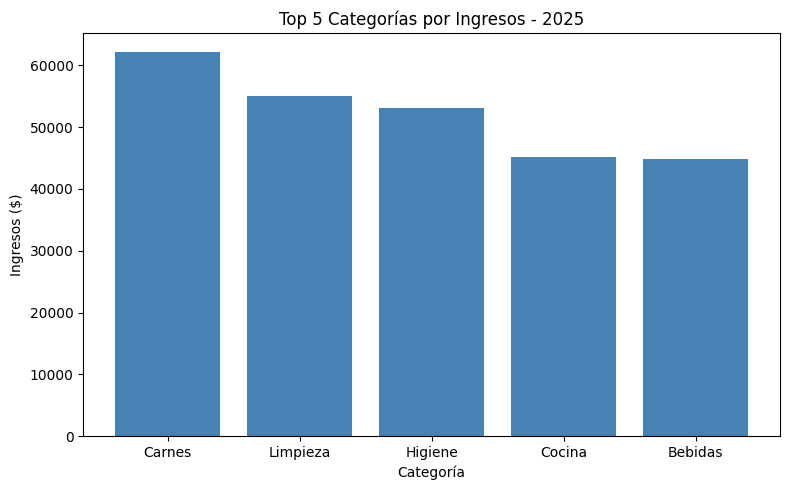

In [13]:
ventas_cat = (
    facturas.groupby("categoria")["total"]
    .sum()
    .sort_values(ascending=False)
)

top5_cat = ventas_cat.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5_cat.index, top5_cat.values, color="steelblue")
plt.title("Top 5 Categorías por Ingresos - 2025")
plt.ylabel("Ingresos ($)")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

In [14]:
facturas["tx_id"] = (
    facturas["fecha"].astype(str)
    + "_"
    + facturas["hora"].astype(str)
    + "_"
    + facturas["cliente"]
)

ticket_por_tx = facturas.groupby("tx_id")["total"].sum()
ticket_promedio = ticket_por_tx.mean()

print("=" * 40)
print("KPI 2 — TICKET PROMEDIO")
print("=" * 40)
print(f"Ticket promedio: ${ticket_promedio:.2f}")
print(f"Transacciones únicas: {len(ticket_por_tx):,}")

KPI 2 — TICKET PROMEDIO
Ticket promedio: $12.15
Transacciones únicas: 35,244


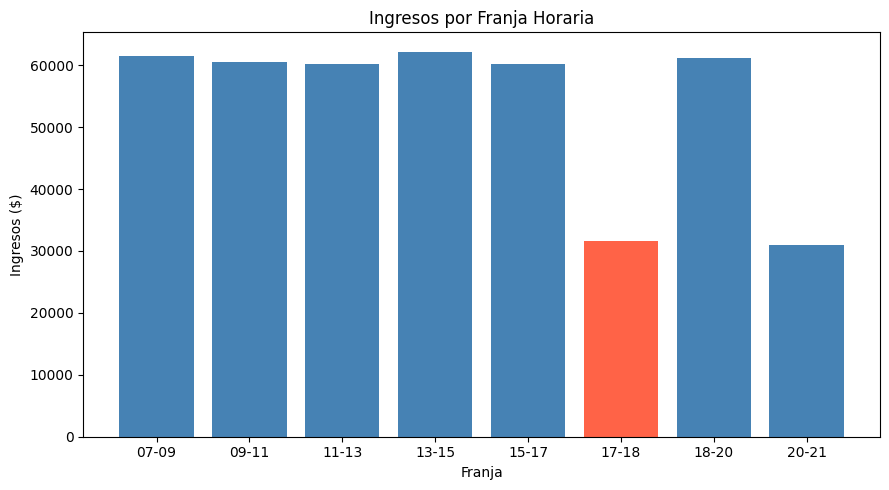

In [15]:
franja_bins = [7, 9, 11, 13, 15, 17, 18, 20, 21]
franja_labels = [
    "07-09","09-11","11-13","13-15",
    "15-17","17-18","18-20","20-21"
]

facturas["franja"] = pd.cut(
    facturas["hora"],
    bins=franja_bins,
    labels=franja_labels,
    right=False
)

ventas_franja = facturas.groupby(
    "franja",
    observed=False
)["total"].sum()

plt.figure(figsize=(9,5))

colores = [
    "steelblue" if x != "17-18" else "tomato"
    for x in ventas_franja.index
]

plt.bar(
    ventas_franja.index,
    ventas_franja.values,
    color=colores
)

plt.title("Ingresos por Franja Horaria")
plt.ylabel("Ingresos ($)")
plt.xlabel("Franja")
plt.tight_layout()
plt.show()

In [16]:
ventas_todas_cat = (
    facturas.groupby("categoria")["total"]
    .sum()
    .sort_values(ascending=False)
)

total = ventas_todas_cat.sum()

for cat, val in ventas_todas_cat.items():
    pct = val / total * 100
    print(f"{cat}: {pct:.2f}%")

Carnes: 14.51%
Limpieza: 12.87%
Higiene: 12.41%
Cocina: 10.53%
Bebidas: 10.47%
Abarrotes: 7.39%
Lácteos: 6.77%
Frutas y Verduras: 6.55%
Granos: 5.45%
Congelados: 5.26%
Panadería: 4.96%
Otros: 2.83%


In [17]:
fig = px.pie(
    names=ventas_todas_cat.index,
    values=ventas_todas_cat.values,
    title="Composición de Ventas por Categoría",
    hole=0.3
)

fig.show()

In [18]:
ventas_cliente = (
    facturas.groupby("cliente")["total"]
    .sum()
    .sort_values(ascending=False)
)

ventas_cliente_df = ventas_cliente.reset_index()
ventas_cliente_df.columns = ["cliente", "total"]

total_general = ventas_cliente_df["total"].sum()

ventas_cliente_df["acumulado_pct"] = (
    ventas_cliente_df["total"].cumsum()
    / total_general * 100
)

clientes_80 = ventas_cliente_df[
    ventas_cliente_df["acumulado_pct"] <= 80
]

print(f"Clientes totales: {len(ventas_cliente_df)}")
print(f"Clientes que generan el 80%: {len(clientes_80)}")

Clientes totales: 100
Clientes que generan el 80%: 78


In [19]:
ventas_cliente = (
    facturas.groupby("cliente")["total"]
    .sum()
    .sort_values(ascending=False)
)

ventas_cliente_df = ventas_cliente.reset_index()
ventas_cliente_df.columns = ["cliente", "total"]

total_general = ventas_cliente_df["total"].sum()

ventas_cliente_df["acumulado_pct"] = (
    ventas_cliente_df["total"].cumsum()
    / total_general * 100
)

clientes_80 = ventas_cliente_df[
    ventas_cliente_df["acumulado_pct"] <= 80
]

print(f"Clientes totales: {len(ventas_cliente_df)}")
print(f"Clientes que generan el 80%: {len(clientes_80)}")

Clientes totales: 100
Clientes que generan el 80%: 78


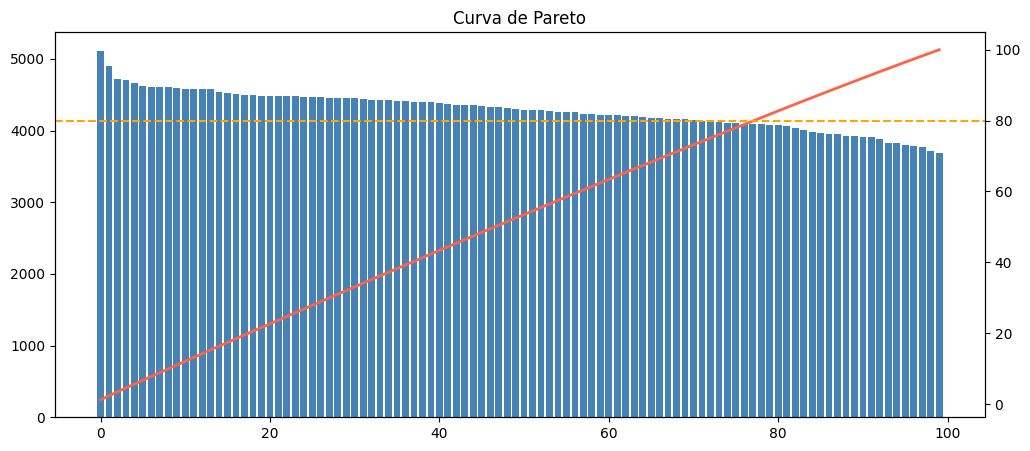

In [20]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.bar(
    range(len(ventas_cliente_df)),
    ventas_cliente_df["total"],
    color="steelblue"
)

ax2 = ax1.twinx()

ax2.plot(
    range(len(ventas_cliente_df)),
    ventas_cliente_df["acumulado_pct"],
    color="tomato",
    linewidth=2
)

ax2.axhline(
    80,
    color="orange",
    linestyle="--"
)

plt.title("Curva de Pareto")
plt.show()

In [21]:
top10_unidades = (
    facturas.groupby("producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10_ingresos = (
    facturas.groupby("producto")["total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top10_unidades)
print(top10_ingresos)

producto
Jugo naranja 1L            1218
Levadura seca 100g         1195
Agua 1500ml                1193
Aguacate 1kg               1189
Salsa picante 150ml        1177
Papa chola 2kg             1160
Carne res molida 500g      1156
Aderezo limón 250ml        1155
Leche semidescremada 1L    1149
Guantes látex par          1146
Name: cantidad, dtype: int64
producto
Ghee 250g               8006.4
Vino tinto 750ml        7912.5
Camarón 500g            6820.4
Crema corporal 400ml    5874.0
Bloqueador 120ml        5871.4
Aceite oliva 500ml      5869.5
Trapeador 1u            5863.8
Aceite coco 250ml       5593.5
Salmón ahumado 100g     5515.8
Bistec res 500g         5472.5
Name: total, dtype: float64


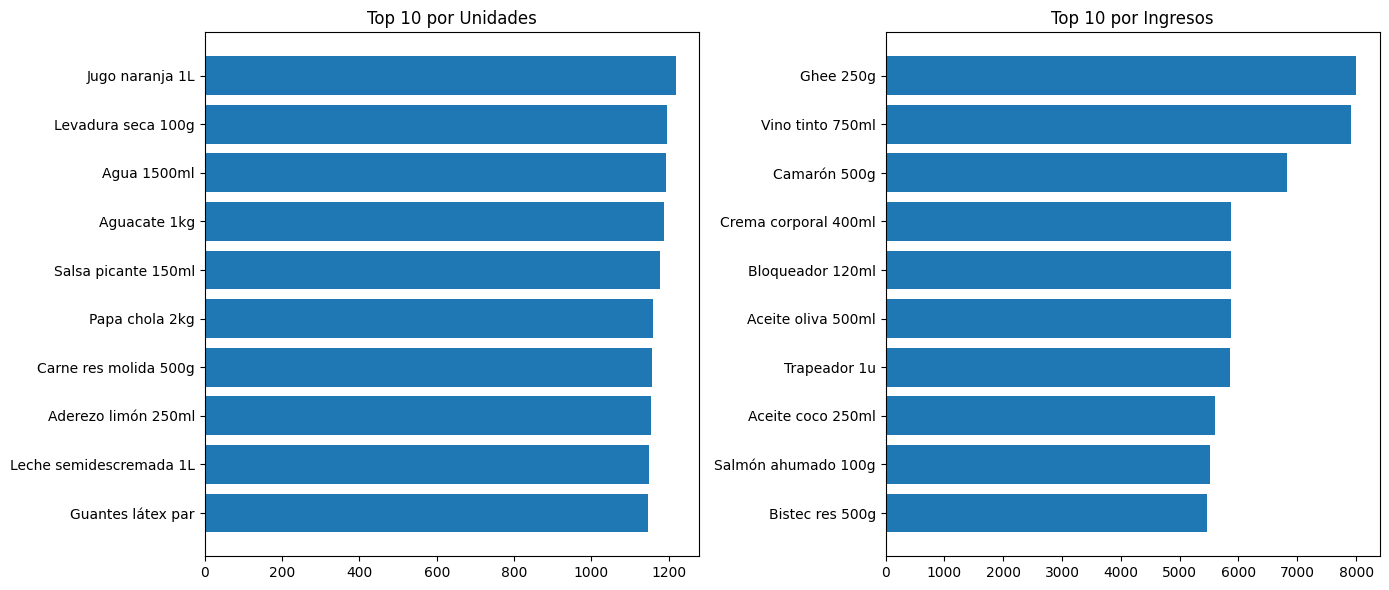

In [22]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,6)
)

ax1.barh(
    top10_unidades.index[::-1],
    top10_unidades.values[::-1]
)

ax1.set_title("Top 10 por Unidades")

ax2.barh(
    top10_ingresos.index[::-1],
    top10_ingresos.values[::-1]
)

ax2.set_title("Top 10 por Ingresos")

plt.tight_layout()
plt.show()

In [23]:
ventas_mes = (
    facturas.groupby(["mes","nombre_mes"])["total"]
    .sum()
    .reset_index()
    .sort_values("mes")
)

ventas_mes

,mes,nombre_mes,total
0,1,Jan,35954.80
1,2,Feb,32001.50
2,3,Mar,35460.20
3,4,Apr,34836.40
4,5,May,36930.50
5,6,Jun,35599.40
6,7,Jul,36559.20
7,8,Aug,36734.00
8,9,Sep,34916.55
9,10,Oct,36549.00


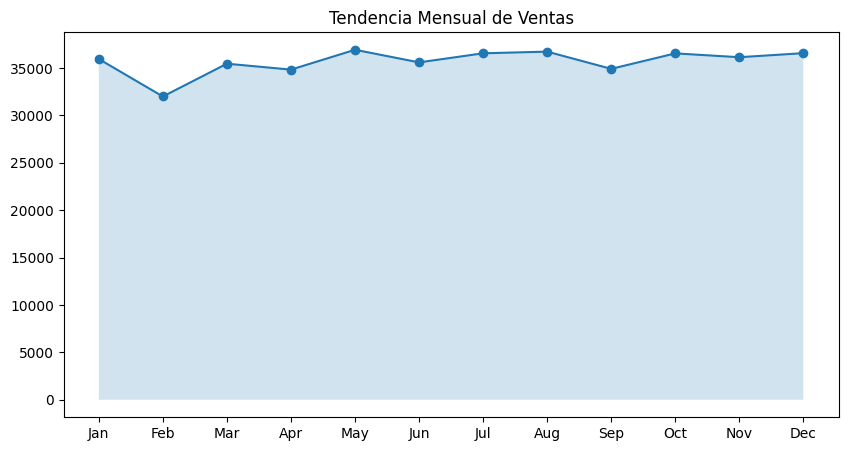

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    ventas_mes["nombre_mes"],
    ventas_mes["total"],
    marker="o"
)

plt.fill_between(
    ventas_mes["nombre_mes"],
    ventas_mes["total"],
    alpha=0.2
)

plt.title("Tendencia Mensual de Ventas")
plt.show()

In [25]:
distribucion_tipo = (
    facturas.groupby("tipo_cliente")["total"]
    .sum()
)

visitas_tipo = (
    facturas["tipo_cliente"]
    .value_counts()
)

print(visitas_tipo)
print(distribucion_tipo)

tipo_cliente
Afiliado       24475
No Afiliado    12025
Name: count, dtype: int64
tipo_cliente
Afiliado       287171.25
No Afiliado    141089.20
Name: total, dtype: float64


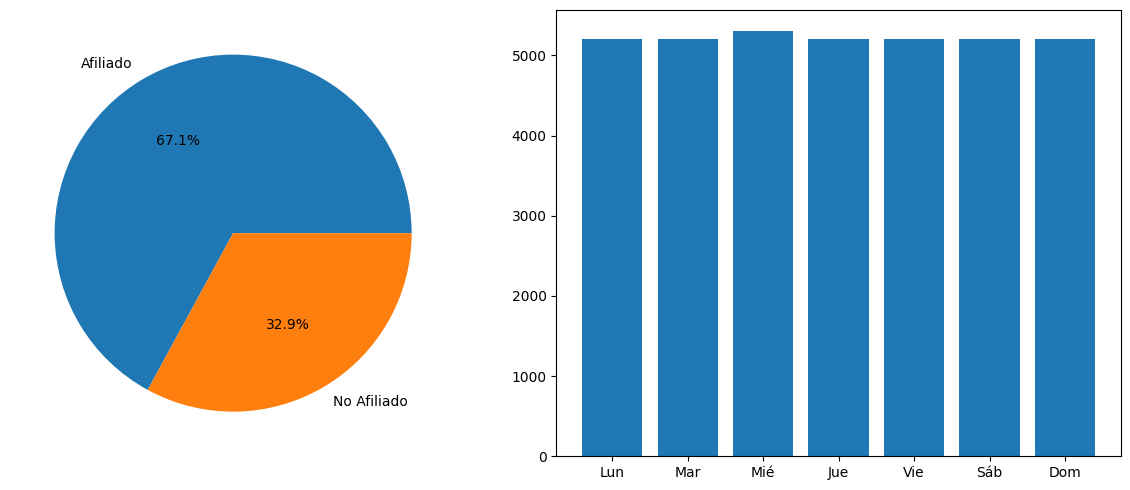

In [26]:
orden_dias = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

nombres_dias = [
    "Lun","Mar","Mié",
    "Jue","Vie","Sáb","Dom"
]

visitas_dia = (
    facturas["dia_semana"]
    .value_counts()
    .reindex(orden_dias)
    .fillna(0)
)

visitas_dia.index = nombres_dias

fig, (ax1, ax2) = plt.subplots(
    1,2,
    figsize=(12,5)
)

ax1.pie(
    distribucion_tipo.values,
    labels=distribucion_tipo.index,
    autopct="%1.1f%%"
)

ax2.bar(
    visitas_dia.index,
    visitas_dia.values
)

plt.tight_layout()
plt.show()

In [27]:
ventas_prod = (
    facturas.groupby("producto")["cantidad"]
    .sum()
    .reset_index()
)

ventas_prod.columns = [
    "nombre",
    "unidades_vendidas"
]

rotacion = productos.merge(
    ventas_prod,
    on="nombre",
    how="left"
)

rotacion["unidades_vendidas"] = (
    rotacion["unidades_vendidas"]
    .fillna(0)
)

rotacion["rotacion"] = (
    rotacion["unidades_vendidas"]
    / rotacion["stock"]
)

rotacion_promedio = (
    rotacion["rotacion"]
    .mean()
)

print(rotacion_promedio)

8.815749232123048


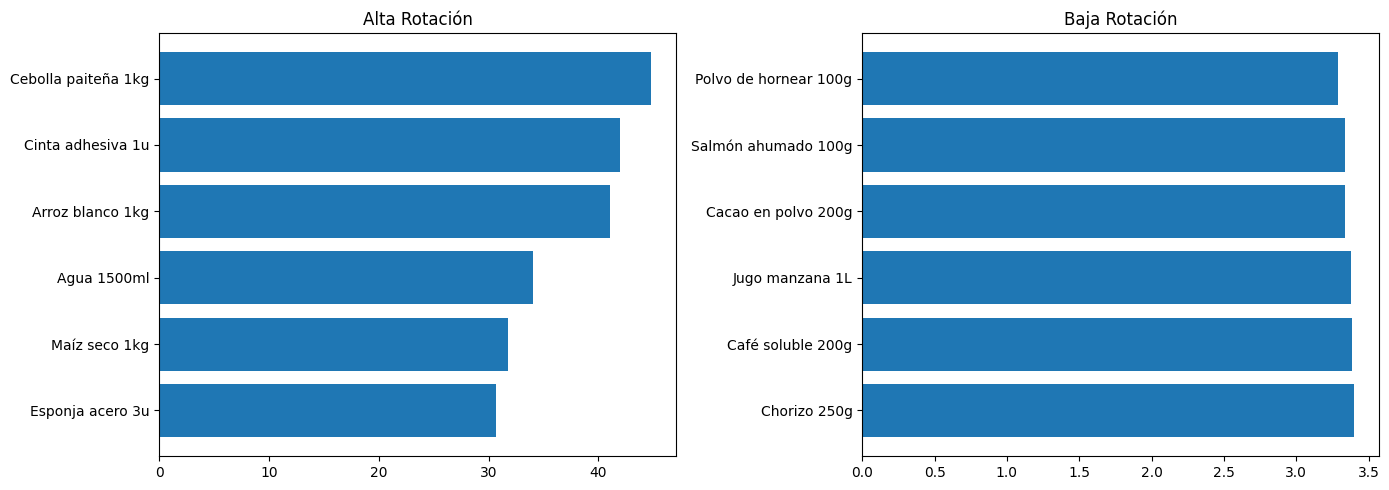

In [28]:
top_alta = rotacion.nlargest(6, "rotacion")
top_baja = rotacion.nsmallest(6, "rotacion")

fig, (ax1, ax2) = plt.subplots(
    1,2,
    figsize=(14,5)
)

ax1.barh(
    top_alta["nombre"][::-1],
    top_alta["rotacion"][::-1]
)

ax1.set_title("Alta Rotación")

ax2.barh(
    top_baja["nombre"][::-1],
    top_baja["rotacion"][::-1]
)

ax2.set_title("Baja Rotación")

plt.tight_layout()
plt.show()